# MLP Semi-Infinite-Domain Hyperparameter Optimization Plot

In [1]:
import numpy as np


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm, Normalize

In [3]:
# Select the completed semi-infinite MLP study.
results_dir = Path("results_mlp_semi_infinite_optuna_2026-09-16_07-04-40")
study_path = results_dir / "data" / "study.csv"
if not study_path.exists():
    raise FileNotFoundError(f"Study file not found: {study_path}")

trials = pd.read_csv(study_path)
trials = trials[trials["state"].eq("COMPLETE")].copy()
trials["objective"] = trials["value"]
trials = trials[trials["objective"] > 0].sort_values("number").reset_index(drop=True)
if trials.empty:
    raise ValueError("The selected MLP result file has no positive completed objectives.")

best_trial = trials.loc[trials["objective"].idxmin()]
print(f"Source: {study_path}")
print(f"Best objective: {best_trial['objective']:.6e}")
for name in ("hidden_layers", "hidden_units", "activation", "learning_rate"):
    print(f"{name}: {best_trial[f'params_{name}']}")

Source: results_mlp_semi_infinite_optuna_2026-09-16_07-04-40/data/study.csv
Best objective: 1.611216e-02
hidden_layers: 3
hidden_units: 104
activation: Tanh
learning_rate: 0.0001


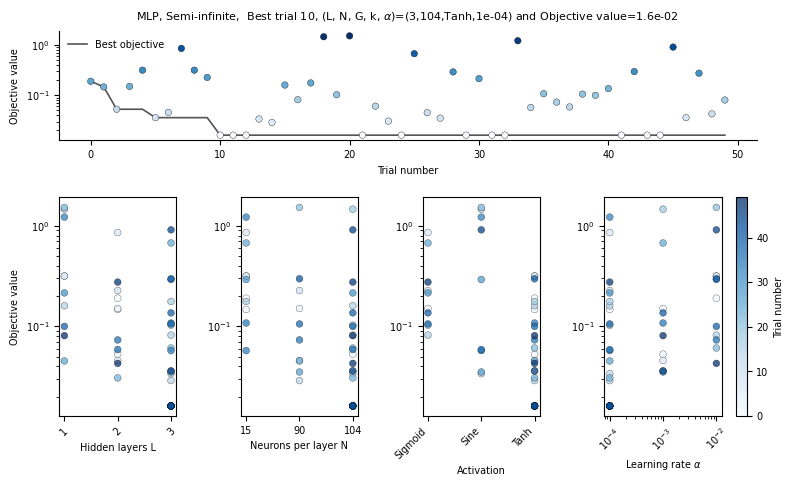

In [10]:
parameter_columns = {
    "hidden_layers": "params_hidden_layers",
    "hidden_units": "params_hidden_units",
    "activation": "params_activation",
    "learning_rate": "params_learning_rate",
}

fig = plt.figure(figsize=(9, 5.0))
grid = fig.add_gridspec(2, 1, height_ratios=(1.0, 2.0), hspace=0.35)

ax_history = fig.add_subplot(grid[0, 0])
best_values = trials["objective"].cummin()
objective_min = trials["objective"].min()
objective_max = trials["objective"].max()
objective_norm = LogNorm(vmin=objective_min, vmax=max(objective_max, objective_min * 1.01))
ax_history.plot(trials["number"], best_values, color="#555555", linewidth=1.2, label="Best objective")
ax_history.scatter(trials["number"], trials["objective"], c=trials["objective"], cmap="Blues", norm=objective_norm, edgecolors="black", linewidths=0.25, s=22, zorder=2)
best_configuration = (
    f"MLP, Semi-infinite,  Best trial {int(best_trial['number'])}, "
    f"(L, N, G, k, $\\alpha$)=({int(best_trial['params_hidden_layers'])},"
    f"{int(best_trial['params_hidden_units'])},"
    f"{best_trial['params_activation']},"
    f"{best_trial['params_learning_rate']:.0e}) and "
    f"Objective value={best_trial['objective']:.1e}"
)
ax_history.set_title(best_configuration, fontsize=8, pad=8)
ax_history.spines["top"].set_visible(False)
ax_history.spines["right"].set_visible(False)
ax_history.set_yscale("log")
ax_history.set_ylabel("Objective value", fontsize=7)
ax_history.set_xlabel("Trial number", fontsize=7)
ax_history.legend(frameon=False, fontsize=7)
ax_history.tick_params(axis="both", labelsize=7)

parameters = list(parameter_columns)
slice_grid = grid[1, 0].subgridspec(1, len(parameters), wspace=0.55)
axes = [fig.add_subplot(slice_grid[0, index]) for index in range(len(parameters))]
trial_norm = Normalize(trials["number"].min(), trials["number"].max())
labels = {"hidden_layers": "Hidden layers L", "hidden_units": "Neurons per layer N", "activation": "Activation", "learning_rate": r"Learning rate $\alpha$"}

for index, (name, column) in enumerate(parameter_columns.items()):
    axis = axes[index]
    values = trials[column]
    if name == "activation":
        categories = sorted(values.astype(str).unique())
        category_positions = {category: position for position, category in enumerate(categories)}
        x_values = values.astype(str).map(category_positions)
        axis.set_xticks(range(len(categories)))
        axis.set_xticklabels(categories, rotation=45, ha="right")
    elif name == "hidden_units":
        categories = [15, 90, 104]
        category_positions = {value: position for position, value in enumerate(categories)}
        numeric_values = pd.to_numeric(values)
        x_values = numeric_values.map(category_positions)
        axis.set_xticks(range(len(categories)))
        axis.set_xticklabels([str(value) for value in categories])
    else:
        x_values = pd.to_numeric(values)

    scatter = axis.scatter(x_values, trials["objective"], c=trials["number"], cmap="Blues", norm=trial_norm, edgecolors="black", linewidths=0.25, alpha=0.75, s=24)
    axis.set_yscale("log")
    axis.set_xlabel(labels[name], fontsize=7)
    if index == 0:
        axis.set_ylabel("Objective value", fontsize=7)
    axis.tick_params(axis="both", labelsize=7)
    if name == "learning_rate":
        axis.set_xscale("log")
    if name not in {"activation", "hidden_units"} and values.nunique() <= 10:
        axis.set_xticks(sorted(pd.to_numeric(values).unique()))
        axis.tick_params(axis="x", rotation=45)

colorbar = fig.colorbar(scatter, ax=axes, pad=0.02, fraction=0.03)
colorbar.set_label("Trial number", fontsize=7)
colorbar.ax.tick_params(labelsize=7)

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)
plt.savefig(figure_dir / "mlp_semi_infinite_hyperparameter_optimization.svg", dpi=300, bbox_inches="tight")
plt.savefig(figure_dir / "mlp_semi_infinite_hyperparameter_optimization.pdf", dpi=300, bbox_inches="tight")
plt.show()